In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.shape

(20640, 9)

In [6]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


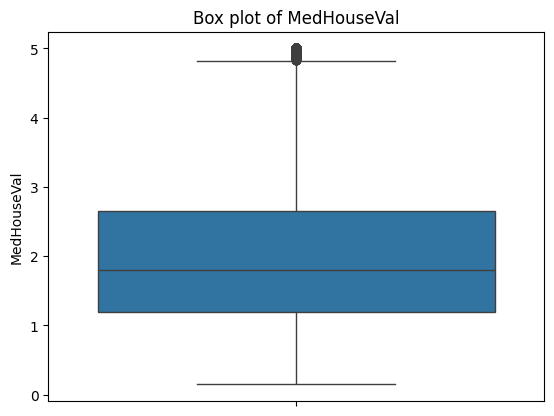

In [9]:
#outlier detection
sns.boxplot(df['MedHouseVal'])
plt.title('Box plot of MedHouseVal')
plt.show()

In [13]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [14]:
df.select_dtypes(include=['number']).columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [55]:
X = df.drop('MedHouseVal', axis=1)
Y = df['MedHouseVal']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


In [57]:
#standardize data
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)

X_test_scaled = scaler_X.transform(X_test)

#Model Building

In [58]:
model = Sequential()
#adding layers
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error',
    metrics = ['mean_absolute_error']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = model.fit(X_train_scaled, Y_train, epochs=100 , batch_size=64, validation_split=0.2)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.9842 - mean_absolute_error: 1.0139 - val_loss: 0.5017 - val_mean_absolute_error: 0.5001
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4611 - mean_absolute_error: 0.4789 - val_loss: 0.4207 - val_mean_absolute_error: 0.4709
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3688 - mean_absolute_error: 0.4337 - val_loss: 0.3934 - val_mean_absolute_error: 0.4490
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3450 - mean_absolute_error: 0.4215 - val_loss: 0.3666 - val_mean_absolute_error: 0.4233
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3225 - mean_absolute_error: 0.4026 - val_loss: 0.3515 - val_mean_absolute_error: 0.4104
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3219 - mean_absolute_error: 0.3994 - val_loss: 0.3421 - val_mean_absolute_error: 0.4000
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3064 - mean_absolute_error: 0.3

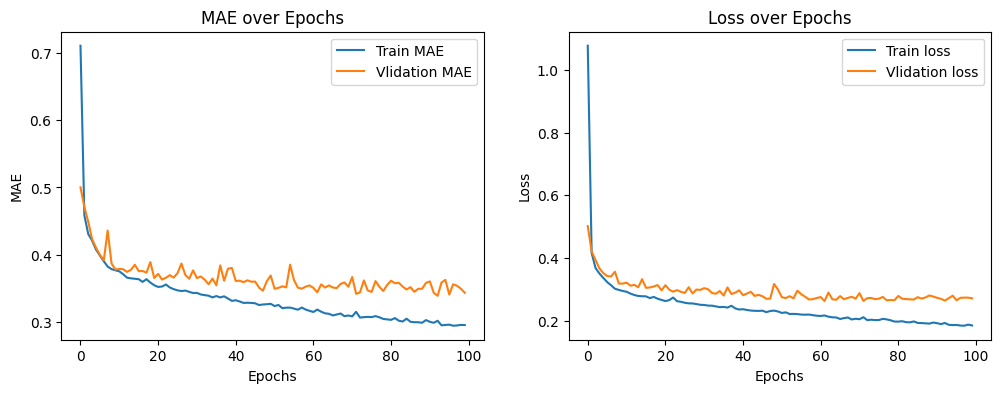

In [60]:
#plot training vs validation MAE and loss
plt.figure(figsize=(12,4))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['mean_absolute_error'], label = 'Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label = 'Vlidation MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Vlidation loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [61]:
Y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [62]:
from sklearn.metrics import r2_score

loss, mae = model.evaluate(X_test_scaled, Y_test)
r2 = r2_score(Y_test, Y_pred)

print(f'Test Loss (MSE): {loss}')
print(f'Test MAE: {mae}')
print(f'Test R-squared: {r2}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2711 - mean_absolute_error: 0.3441
Test Loss (MSE): 0.27446702122688293
Test MAE: 0.3423401415348053
Test R-squared: 0.7905485009412003


In [64]:
df.head(1)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526


In [69]:
# Create sample data for a single house with the same columns as the training data
single_house_data = {
    'MedInc': [3.5],
    'HouseAge': [20.0],
    'AveRooms': [7.9],
    'AveBedrms': [1.0],
    'Population': [400.0],
    'AveOccup': [3.6667],
    'Latitude':[34.0],
    'Longitude': [-118.0]
}
single_house_df = pd.DataFrame(single_house_data)

# Preprocess the single house data using the same scaler
single_house_scaled = scaler_X.transform(single_house_df)

# Predict on the single house data
predicted_price = model.predict(single_house_scaled)

#Display the predicted price
predicted_price_usd = predicted_price[0][0]*100000
print("Predicted House Price in Dollars: ${:,.2f}".format(predicted_price_usd))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted House Price in Dollars: $381,542.44
